# Breast Cancer Tumor Classification using Neural Networks

This project aims to classify breast tumors as **benign** or **malignant** using a neural network model.

The dataset used is the **Breast Cancer Wisconsin Diagnostic Dataset**, which contains features computed from digitized images of fine needle aspirate (FNA) of breast masses.

The workflow of this notebook includes:

1. Importing libraries and loading the dataset
2. Exploratory Data Analysis (EDA)
3. Data preprocessing
4. Building a neural network model
5. Training the model
6. Evaluating the model performance

## Importing Required Libraries

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Loading the Dataset

The dataset is loaded using pandas. We then display the first few rows to understand its structure.

In [33]:
df = pd.read_csv('breast_cancer_wisconsin_diagnostic.csv')

In [34]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,...,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12
1,842517,M,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,...,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
2,84300903,M,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,...,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
3,84348301,M,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,...,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17
4,84358402,M,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,...,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08


## Data Preprocessing

In [35]:
# Drop the 'id' column because it's a unique identifier and has no predictive power for the model.
df = df.drop('id', axis=1)
#Disable scientific notation to make the statistical summary easier to read and interpret.
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# Convert categorical labels ('M'/'B') into numerical values (1/0) so the neural network can process them.
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
# Rename the column to clearly indicate the binary encoding (0 for Benign, 1 for Malignant).
df = df.rename(columns={'diagnosis': 'benign_0__mal_1'})
# Display the first 5 rows to verify that all changes were applied correctly.
df.head()

,benign_0__mal_1,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,0.24,...,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12
1,1,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,0.18,...,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
2,1,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,0.21,...,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
3,1,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,0.26,...,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17
4,1,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,0.18,...,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08


## Dataset Overview

We inspect the dataset to understand the number of features, data types, and whether there are missing values.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   benign_0__mal_1          569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave_points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Descriptive Statistics

We analyze basic statistical properties of the dataset such as mean, standard deviation, and range for each feature.

In [26]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
benign_0__mal_1,569.00,0.37,0.48,0.00,0.00,0.00,1.00,1.00
radius_mean,569.00,14.13,3.52,6.98,11.70,13.37,15.78,28.11
texture_mean,569.00,19.29,4.30,9.71,16.17,18.84,21.80,39.28
perimeter_mean,569.00,91.97,24.30,43.79,75.17,86.24,104.10,188.50
area_mean,569.00,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
smoothness_mean,569.00,0.10,0.01,0.05,0.09,0.10,0.11,0.16
compactness_mean,569.00,0.10,0.05,0.02,0.06,0.09,0.13,0.35
concavity_mean,569.00,0.09,0.08,0.00,0.03,0.06,0.13,0.43
concave_points_mean,569.00,0.05,0.04,0.00,0.02,0.03,0.07,0.20
symmetry_mean,569.00,0.18,0.03,0.11,0.16,0.18,0.20,0.30


## Target Variable Distribution

We visualize the distribution of the target variable to check if the dataset is balanced between benign and malignant cases.

Text(0.5, 1.0, 'Distribution of Tumor Diagnosis')

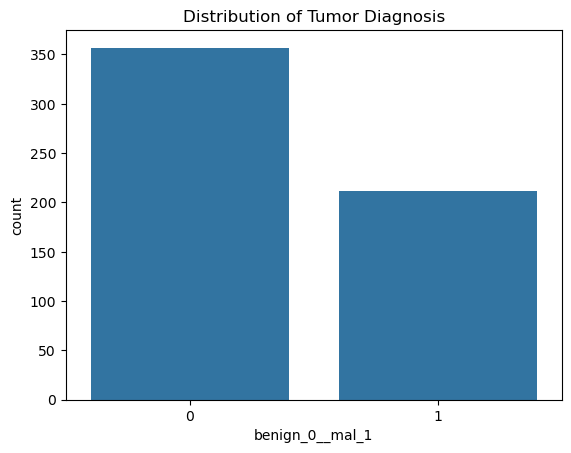

In [27]:
sns.countplot(x='benign_0__mal_1', data=df)
plt.title("Distribution of Tumor Diagnosis")

## Correlation Analysis

A correlation matrix helps identify relationships between variables and detect highly correlated features.

<Axes: >

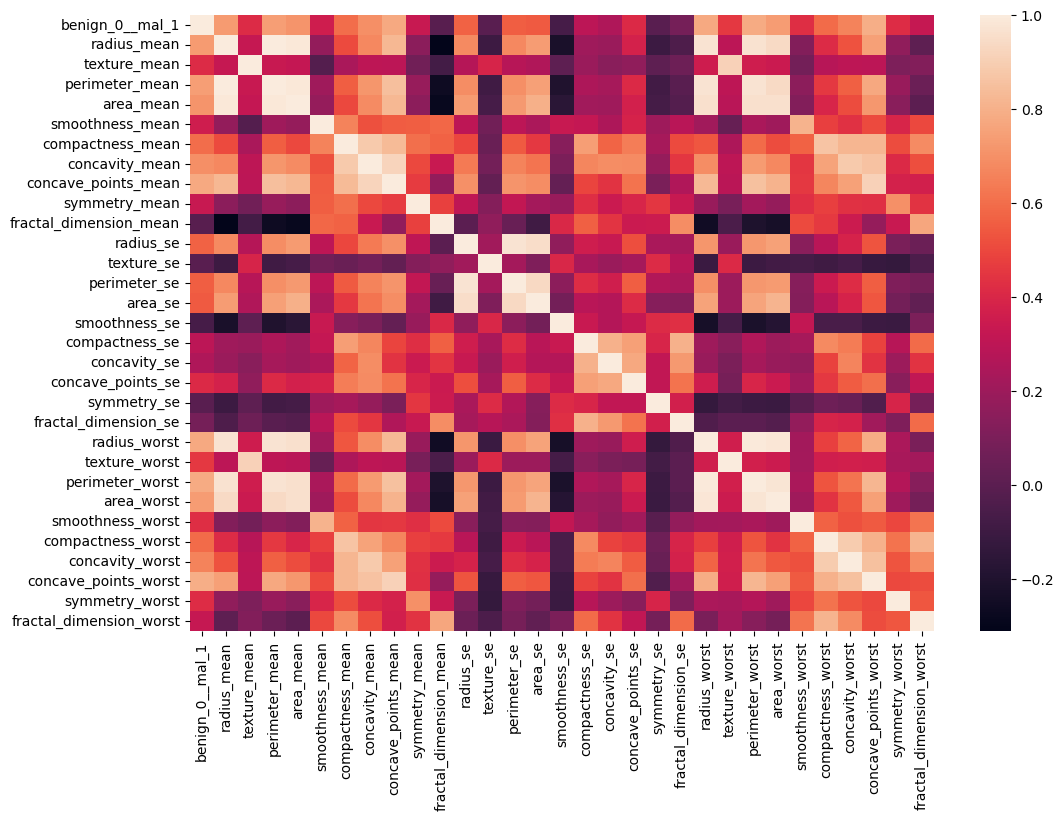

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr())

## Correlation with the Target Variable

We analyze which features are most correlated with the diagnosis outcome.

In [38]:
df.corr()['benign_0__mal_1'].sort_values()

smoothness_se             -0.07
fractal_dimension_mean    -0.01
texture_se                -0.01
symmetry_se               -0.01
fractal_dimension_se       0.08
concavity_se               0.25
compactness_se             0.29
fractal_dimension_worst    0.32
symmetry_mean              0.33
smoothness_mean            0.36
concave_points_se          0.41
texture_mean               0.42
symmetry_worst             0.42
smoothness_worst           0.42
texture_worst              0.46
area_se                    0.55
perimeter_se               0.56
radius_se                  0.57
compactness_worst          0.59
compactness_mean           0.60
concavity_worst            0.66
concavity_mean             0.70
area_mean                  0.71
radius_mean                0.73
area_worst                 0.73
perimeter_mean             0.74
radius_worst               0.78
concave_points_mean        0.78
perimeter_worst            0.78
concave_points_worst       0.79
benign_0__mal_1            1.00
Name: be

We exclude the target variable itself ([:-1]) to prevent the 1.0 correlation

<Axes: >

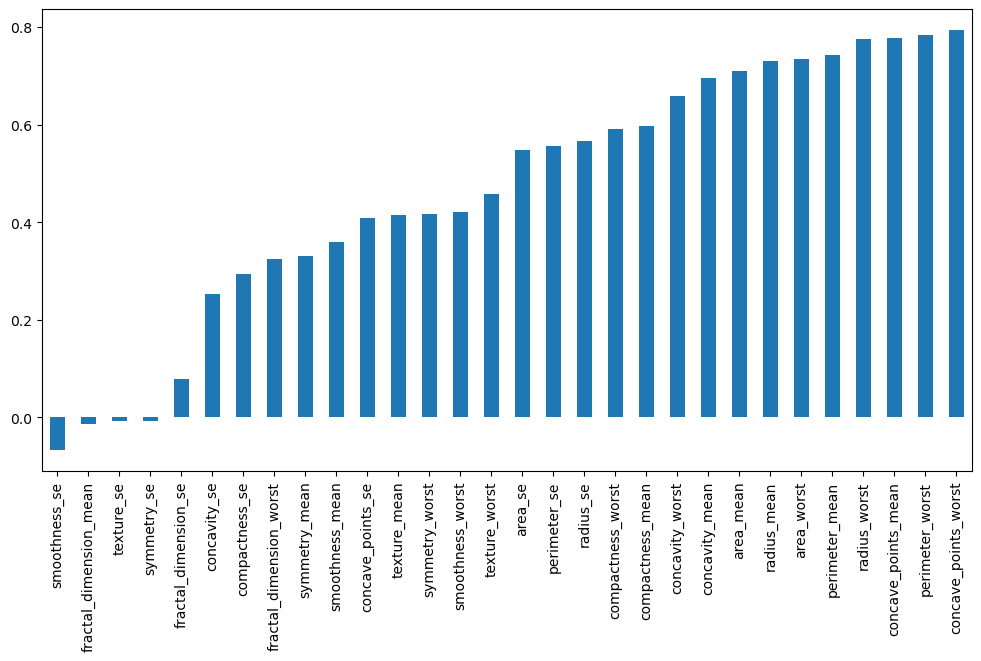

In [40]:
df.corr()['benign_0__mal_1'].drop('benign_0__mal_1').sort_values().plot(kind='bar', figsize=(12,6))

## Preparing the Data

We separate the dataset into:

- **X** → input features  
- **y** → target variable

In [43]:
X = df.drop('benign_0__mal_1', axis=1).values
y = df['benign_0__mal_1'].values

## Splitting the Dataset

The dataset is divided into training and testing sets to evaluate the model's ability to generalize to unseen data.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=101
)

## Feature Scaling

Neural networks perform better when input features are normalized.  
We use MinMaxScaler to scale all features between 0 and 1.

In [47]:
from sklearn.preprocessing import MinMaxScaler

In [48]:
scaler = MinMaxScaler()

In [49]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Building the Neural Network

We construct a simple neural network using TensorFlow/Keras with:

- Dense layers
- ReLU activation
- Dropout layers to reduce overfitting

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [51]:
model = Sequential()

model.add(Dense(30, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(15, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam'
)

## Early Stopping

Early stopping prevents overfitting by stopping training when validation loss stops improving.

In [52]:
from tensorflow.keras.callbacks import EarlyStopping

In [53]:
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=25,
    verbose=1
)

## Training the Model

The model is trained using the training dataset while monitoring performance on the validation set.

In [54]:
model.fit(
    X_train,
    y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.6960 - val_loss: 0.6738
Epoch 2/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6710 - val_loss: 0.6430
Epoch 3/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6501 - val_loss: 0.6248
Epoch 4/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6420 - val_loss: 0.6059
Epoch 5/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6113 - val_loss: 0.5887
Epoch 6/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5992 - val_loss: 0.5654
Epoch 7/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5906 - val_loss: 0.5405
Epoch 8/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5414 - val_loss: 0.5113
Epoch 9/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5346 - val_loss: 0.4767
Epoch 10/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5268 - val_loss: 0.4489
Epoch 11/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4940 - val_loss: 0.4203
Epoch 12/600
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - los

## Training Performance

We visualize the training and validation loss to analyze model performance and detect possible overfitting.

<Axes: >

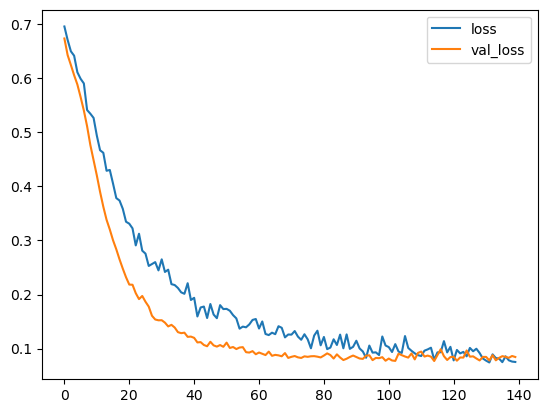

In [55]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

## Model Evaluation

Finally, we evaluate the model using a classification report and confusion matrix.

In [56]:
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [59]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        88
           1       0.96      0.98      0.97        55

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [60]:
print(confusion_matrix(y_test, predictions))

[[86  2]
 [ 1 54]]


## Conclusion

The neural network achieves a high classification accuracy in distinguishing between benign and malignant tumors.

Techniques such as **dropout regularization** and **early stopping** help reduce overfitting and improve model generalization.